# Multivariate Gaussian Model Application

### Standard Gaussian Model

In [1]:
from utils import *
from gaussian_utils import *
import numpy as np

D, L = load("train_data.txt")
(D_training, L_training), (D_eval, L_eval) = split_db_2to1(D, L)

parameters = compute_theta_parameters_per_class(D_training, L_training)

scores = compute_ll_per_class(D_eval, parameters) 

Pc0 = (1/2) # prior class 0
Pc1 = (1/2) # prior class 1

threshold = - (np.log(Pc1/Pc0))

log_likelihood_ratios = scores[1, :] - scores[0, :]

predictions = log_likelihood_ratios >= threshold

accuracy = ((predictions == L_eval).sum()) / L_eval.shape[0]

print(f"Accuracy: {accuracy:.2f}")
print(f"Error rate: {(1-accuracy):.2f}")

Accuracy: 0.93
Error rate: 0.07


### Tied Gaussian Model

In this model we will use the same (mean) covariance matrix

In [2]:
C = (parameters[0][1]*(L_training == 0).sum()  \
    + parameters[1][1]*(L_training == 1).sum()) \
    / L_training.shape[0] # weighted mean covariance matrix : (C1*samples1 + C2*samples2) / tot_samples)

parameters_tied = [(parameters[0][0], C), (parameters[1][0], C)]

scores = compute_ll_per_class(D_eval, parameters_tied) 

log_likelihood_ratios = scores[1, :] - scores[0, :]

predictions = log_likelihood_ratios >= threshold

accuracy = ((predictions == L_eval).sum()) / L_eval.shape[0]

print(f"Accuracy: {accuracy:.2f}")
print(f"Error rate: {(1-accuracy):.2f}")

Accuracy: 0.91
Error rate: 0.09


### Naive Gaussian Model

Now we consider zero covariance between features

In [3]:
naive_parameters = []

for i in range(2):
    cov_mat = parameters[i][1] * np.identity(parameters[i][1].shape[0]) # A * I to obtain only diagona elements
    naive_parameters.append((parameters[i][0], cov_mat))

scores = compute_ll_per_class(D_eval, naive_parameters) 

log_likelihood_ratios = scores[1, :] - scores[0, :]

predictions = log_likelihood_ratios >= threshold

accuracy = ((predictions == L_eval).sum()) / L_eval.shape[0]

print(f"Accuracy: {accuracy:.2f}")
print(f"Error rate: {(1-accuracy):.2f}")

Accuracy: 0.93
Error rate: 0.07


### Why Naive performs like the standard model?

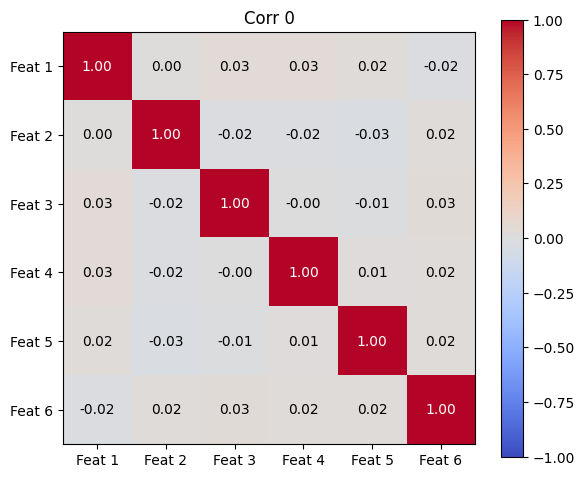

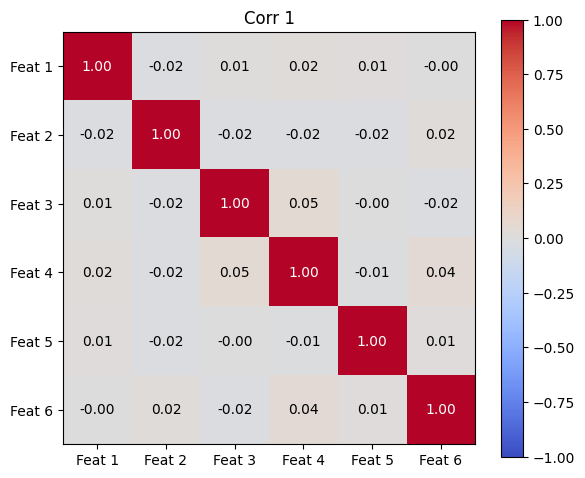

In [4]:
C0 = parameters[0][1]
C1 = parameters[1][1]

Corr_0 = C0 / (vcol(C0.diagonal()**0.5) * vrow(C0.diagonal()**0.5))
Corr_1 = C1 / (vcol(C1.diagonal()**0.5) * vrow(C1.diagonal()**0.5))

print_corr(Corr_0, title="Corr 0")
print_corr(Corr_1, title="Corr 1")


### Trying classification without features 5 and 6

We will now remove feature 5 and 6 beacause they don't perfectly fit standard distribution assumptions.
In order:
- Standard Gaussian Model
- Tied Gaussian Model
- Naive Gaussian Model

In [5]:
D = D[:4, :]
(D_training, L_training), (D_eval, L_eval) = split_db_2to1(D, L)

parameters = compute_theta_parameters_per_class(D_training, L_training)

scores = compute_ll_per_class(D_eval, parameters) 

Pc0 = (1/2) # prior class 0
Pc1 = (1/2) # prior class 1

threshold = - (np.log(Pc1/Pc0))

log_likelihood_ratios = scores[1, :] - scores[0, :]

predictions = log_likelihood_ratios >= threshold

accuracy = ((predictions == L_eval).sum()) / L_eval.shape[0]

print(f"Accuracy: {accuracy:.2f}")
print(f"Error rate: {(1-accuracy):.2f}")

Accuracy: 0.92
Error rate: 0.08


In [6]:
C = (parameters[0][1]*(L_training == 0).sum()  \
    + parameters[1][1]*(L_training == 1).sum()) \
    / L_training.shape[0] # weighted mean covariance matrix : (C1*samples1 + C2*samples2) / tot_samples)

parameters_tied = [(parameters[0][0], C), (parameters[1][0], C)]

scores = compute_ll_per_class(D_eval, parameters_tied) 

log_likelihood_ratios = scores[1, :] - scores[0, :]

predictions = log_likelihood_ratios >= threshold

accuracy = ((predictions == L_eval).sum()) / L_eval.shape[0]

print(f"Accuracy: {accuracy:.2f}")
print(f"Error rate: {(1-accuracy):.2f}")

Accuracy: 0.91
Error rate: 0.09


In [7]:
naive_parameters = []

for i in range(2):
    cov_mat = parameters[i][1] * np.identity(parameters[i][1].shape[0]) # A * I to obtain only diagona elements
    naive_parameters.append((parameters[i][0], cov_mat))

scores = compute_ll_per_class(D_eval, naive_parameters) 

log_likelihood_ratios = scores[1, :] - scores[0, :]

predictions = log_likelihood_ratios >= threshold

accuracy = ((predictions == L_eval).sum()) / L_eval.shape[0]

print(f"Accuracy: {accuracy:.2f}")
print(f"Error rate: {(1-accuracy):.2f}")

Accuracy: 0.92
Error rate: 0.08


The accuracy drops!

## Applying PCA before the model

In [8]:
from dimensionality_reduction import *

D, L = load("train_data.txt")
(D_training, L_training), (D_eval, L_eval) = split_db_2to1(D, L)

num_target_dimensions = 5

U = PCA(D_training, num_target_dimensions)
D_training = U.T@D_training
D_eval = U.T@D_eval

parameters = compute_theta_parameters_per_class(D_training, L_training)

scores = compute_ll_per_class(D_eval, parameters) 

Pc0 = (1/2) # prior class 0
Pc1 = (1/2) # prior class 1

threshold = - (np.log(Pc1/Pc0))

log_likelihood_ratios = scores[1, :] - scores[0, :]

predictions = log_likelihood_ratios >= threshold

accuracy = ((predictions == L_eval).sum()) / L_eval.shape[0]

print(f"Accuracy: {accuracy:.2f}")
print(f"Error rate: {(1-accuracy):.2f}")

Accuracy: 0.93
Error rate: 0.07


In [9]:
C = (parameters[0][1]*(L_training == 0).sum()  \
    + parameters[1][1]*(L_training == 1).sum()) \
    / L_training.shape[0] # weighted mean covariance matrix : (C1*samples1 + C2*samples2) / tot_samples)

parameters_tied = [(parameters[0][0], C), (parameters[1][0], C)]

scores = compute_ll_per_class(D_eval, parameters_tied) 

log_likelihood_ratios = scores[1, :] - scores[0, :]

predictions = log_likelihood_ratios >= threshold

accuracy = ((predictions == L_eval).sum()) / L_eval.shape[0]

print(f"Accuracy: {accuracy:.2f}")
print(f"Error rate: {(1-accuracy):.2f}")

Accuracy: 0.91
Error rate: 0.09


In [10]:
naive_parameters = []

for i in range(2):
    cov_mat = parameters[i][1] * np.identity(parameters[i][1].shape[0]) # A * I to obtain only diagona elements
    naive_parameters.append((parameters[i][0], cov_mat))

scores = compute_ll_per_class(D_eval, naive_parameters) 

log_likelihood_ratios = scores[1, :] - scores[0, :]

predictions = log_likelihood_ratios >= threshold

accuracy = ((predictions == L_eval).sum()) / L_eval.shape[0]

print(f"Accuracy: {accuracy:.2f}")
print(f"Error rate: {(1-accuracy):.2f}")

Accuracy: 0.91
Error rate: 0.09


## Model Evaluation

### Assumptions:

In [11]:
effective_priors_scenarios = [0.1, 0.5, 0.9] # 3 different sccenarios for the same application
C_fn = 1
C_fp = 1

### Standard Gaussian Model

Scenario pi = 0.1:

Confusion Matrix:
               Class 0         Class 1         

Class 0        988             271             

Class 1        4               737             

Actual DCF: 0.3051395289298515
Minimum DCF: 0.2629128264208909
Calibration error = 0.0422267025089606

Scenario pi = 0.5:

Confusion Matrix:
               Class 0         Class 1         

Class 0        927             75              

Class 1        65              933             

Actual DCF: 0.13992895545314898
Minimum DCF: 0.13016833077316947
Calibration error = 0.009760624679979513

Scenario pi = 0.9:

Confusion Matrix:
               Class 0         Class 1         

Class 0        728             15              

Class 1        264             993             

Actual DCF: 0.40005760368663595
Minimum DCF: 0.34230990783410137
Calibration error = 0.057747695852534586



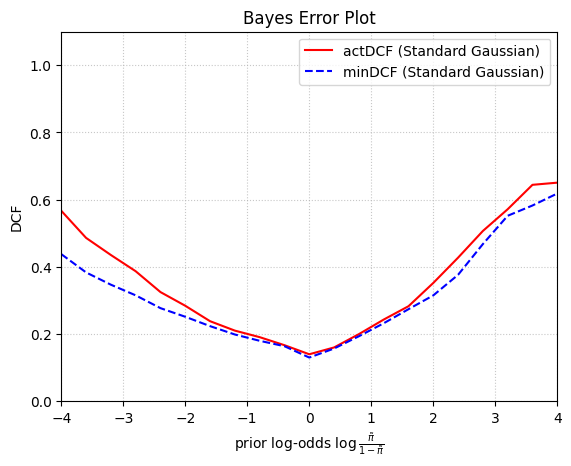

In [12]:
D, L = load("train_data.txt")
(D_training, L_training), (D_eval, L_eval) = split_db_2to1(D, L)

parameters = compute_theta_parameters_per_class(D_training, L_training)

scores = compute_ll_per_class(D_eval, parameters) 

log_likelihood_ratios = scores[1, :] - scores[0, :]

for pi in effective_priors_scenarios:
    print("======================================================")
    predictions = compute_optimal_bayes(log_likelihood_ratios, pi, C_fn, C_fp)
    print(f"Scenario pi = {pi}:")
    print("\nConfusion Matrix:") 
    print_binary_confusion_matrix(predictions, L_eval)
    DCF = compute_act_dcf(log_likelihood_ratios, L_eval, pi, C_fn, C_fp)
    print(f"Actual DCF: {DCF}")
    minDCF = compute_min_dcf(log_likelihood_ratios, L_eval, pi, C_fn, C_fp)
    print(f"Minimum DCF: {minDCF}")
    print(f"Calibration error = {DCF - minDCF}\n")

plot_bayes_error(log_likelihood_ratios, L_eval, label="Standard Gaussian")

### Tied Gaussian Model

Scenario pi = 0.1:

Confusion Matrix:
               Class 0         Class 1         

Class 0        983             327             

Class 1        9               681             

Actual DCF: 0.4060579877112135
Minimum DCF: 0.36283922171018945
Calibration error = 0.043218766001024034

Scenario pi = 0.5:

Confusion Matrix:
               Class 0         Class 1         

Class 0        898             92              

Class 1        94              916             

Actual DCF: 0.18602790578597028
Minimum DCF: 0.18124359959037378
Calibration error = 0.004784306195596499

Scenario pi = 0.9:

Confusion Matrix:
               Class 0         Class 1         

Class 0        666             15              

Class 1        326             993             

Actual DCF: 0.46255760368663595
Minimum DCF: 0.4421082949308756
Calibration error = 0.020449308755760343



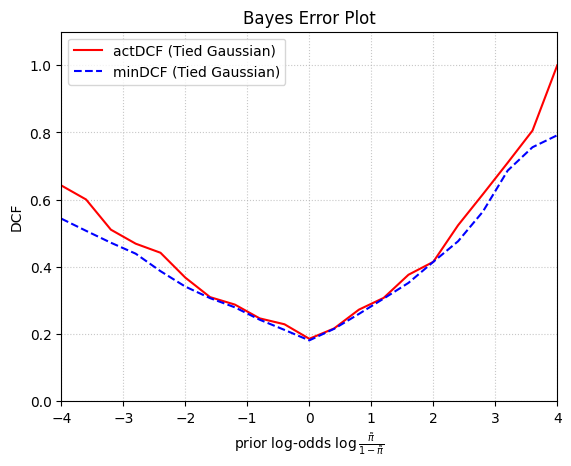

In [13]:
C = (parameters[0][1]*(L_training == 0).sum()  \
    + parameters[1][1]*(L_training == 1).sum()) \
    / L_training.shape[0] # weighted mean covariance matrix : (C1*samples1 + C2*samples2) / tot_samples)

parameters_tied = [(parameters[0][0], C), (parameters[1][0], C)]

scores = compute_ll_per_class(D_eval, parameters_tied) 

log_likelihood_ratios = scores[1, :] - scores[0, :]

for pi in effective_priors_scenarios:
    print("======================================================")
    predictions = compute_optimal_bayes(log_likelihood_ratios, pi, C_fn, C_fp)
    print(f"Scenario pi = {pi}:")
    print("\nConfusion Matrix:") 
    print_binary_confusion_matrix(predictions, L_eval)
    DCF = compute_act_dcf(log_likelihood_ratios, L_eval, pi, C_fn, C_fp)
    print(f"Actual DCF: {DCF}")
    minDCF = compute_min_dcf(log_likelihood_ratios, L_eval, pi, C_fn, C_fp)
    print(f"Minimum DCF: {minDCF}")
    print(f"Calibration error = {DCF - minDCF}\n")

plot_bayes_error(log_likelihood_ratios, L_eval, label="Tied Gaussian")

### Naive Gaussian Model

Scenario pi = 0.1:

Confusion Matrix:
               Class 0         Class 1         

Class 0        988             268             

Class 1        4               740             

Actual DCF: 0.30216333845366106
Minimum DCF: 0.25696044546851
Calibration error = 0.045202892985151066

Scenario pi = 0.5:

Confusion Matrix:
               Class 0         Class 1         

Class 0        925             77              

Class 1        67              931             

Actual DCF: 0.14392921146953405
Minimum DCF: 0.1311283922171019
Calibration error = 0.01280081925243215

Scenario pi = 0.9:

Confusion Matrix:
               Class 0         Class 1         

Class 0        721             13              

Class 1        271             995             

Actual DCF: 0.38925691244239635
Minimum DCF: 0.3509504608294931
Calibration error = 0.03830645161290325



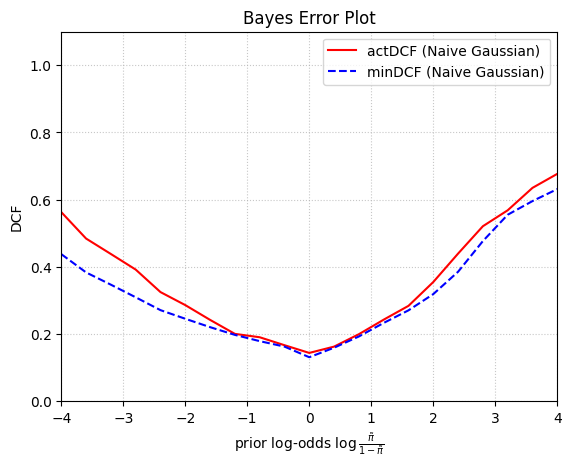

In [14]:
naive_parameters = []

for i in range(2):
    cov_mat = parameters[i][1] * np.identity(parameters[i][1].shape[0]) # A * I to obtain only diagona elements
    naive_parameters.append((parameters[i][0], cov_mat))

scores = compute_ll_per_class(D_eval, naive_parameters) 

log_likelihood_ratios = scores[1, :] - scores[0, :]

for pi in effective_priors_scenarios:
    print("======================================================")
    predictions = compute_optimal_bayes(log_likelihood_ratios, pi, C_fn, C_fp)
    print(f"Scenario pi = {pi}:")
    print("\nConfusion Matrix:") 
    print_binary_confusion_matrix(predictions, L_eval)
    DCF = compute_act_dcf(log_likelihood_ratios, L_eval, pi, C_fn, C_fp)
    print(f"Actual DCF: {DCF}")
    minDCF = compute_min_dcf(log_likelihood_ratios, L_eval, pi, C_fn, C_fp)
    print(f"Minimum DCF: {minDCF}")
    print(f"Calibration error = {DCF - minDCF}\n")

plot_bayes_error(log_likelihood_ratios, L_eval, label="Naive Gaussian")